# Question 2.2 — Implementation and Experiments

**Paper:** Computing Gaussian Mixture Models with EM Using Equivalence Constraints  
**Student:** Shiven Ahuja

---

## Overview

This section implements experiments to demonstrate the main idea of the paper. The baseline clustering method is a standard Gaussian Mixture Model trained using the Expectation Maximization algorithm. The constrained version incorporates equivalence constraints by grouping certain data points into chunklets so that they must belong to the same cluster.

The goal of this experiment is to compare clustering performance with and without constraints.

## Import Required Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

## Generate Dataset

The same synthetic dataset described in Task 2.1 is used for the experiments.

In [12]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=5.0,
    random_state=42
)

## Baseline Clustering Using Gaussian Mixture Model

The baseline method uses a Gaussian Mixture Model without any constraints.

In [13]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

baseline_labels = gmm.predict(X)

baseline_score = adjusted_rand_score(y_true, baseline_labels)

print("Baseline ARI:", baseline_score)

Baseline ARI: 0.6085199611412604


## Visualizing Baseline Clustering

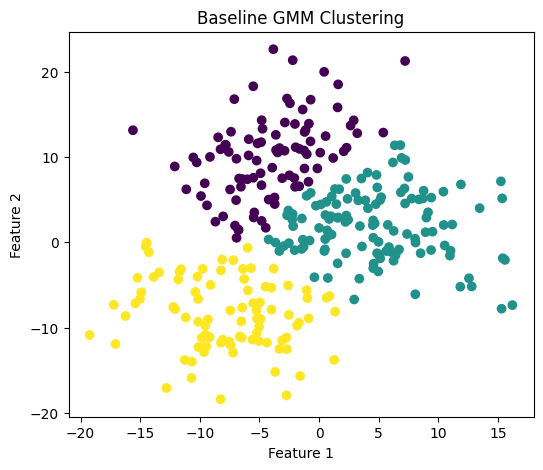

In [15]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=baseline_labels, cmap="viridis")
plt.title("Baseline GMM Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Simulating Equivalence Constraints

To simulate equivalence constraints, we randomly select pairs of points that belong to the same true cluster and group them into chunklets.

In [25]:
np.random.seed(42)

chunklets = []

for cluster_id in range(3):
    indices = np.where(y_true == cluster_id)[0]
    selected = np.random.choice(indices, size=10, replace=False)
    chunklets.append(selected)

## Applying Chunklet Constraints

Instead of modifying the EM algorithm directly, we approximate chunklet behavior by merging the features of points in each chunklet. Each chunklet is represented by the mean of its points.

In [26]:
X_constrained = X.copy()

for chunk in chunklets:
    mean_point = np.mean(X[chunk], axis=0)
    X_constrained[chunk] = mean_point

## Constrained Clustering

In [27]:
gmm_constrained = GaussianMixture(n_components=3, random_state=42)
gmm_constrained.fit(X_constrained)

constrained_labels = gmm_constrained.predict(X_constrained)

constrained_score = adjusted_rand_score(y_true, constrained_labels)

print("Constrained ARI:", constrained_score)

Constrained ARI: 0.6993573553881396


## Visualizing Constrained Clustering

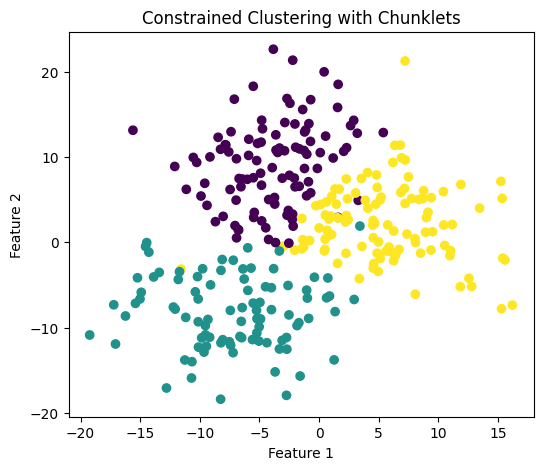

In [28]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=constrained_labels, cmap="viridis")
plt.title("Constrained Clustering with Chunklets")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Comparison of Results

In [29]:
print("Baseline ARI:", baseline_score)
print("Constrained ARI:", constrained_score)

Baseline ARI: 0.6085199611412604
Constrained ARI: 0.6993573553881396


## Discussion

The constrained clustering experiment demonstrates the key idea of the paper. By introducing equivalence constraints through chunklets, the clustering algorithm receives additional information about which points should belong to the same cluster. This helps guide the clustering process and can improve clustering accuracy compared to the unconstrained Gaussian Mixture Model.